# Grid Operations

This notebook demonstrates the grid operations available in `bathy`:
- **clip** - Clip a grid to a polygon or region preset
- **resample** - Change grid resolution (by degrees or metres)
- **reproject** - Transform to a different coordinate reference system
- **merge** - Combine multiple grids with overlap handling
- **fill_gaps** - Interpolate over NaN gaps

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box

import bathy

# Load sample data (Celtic Sea/Bay of Biscay, GEBCO 2025)
data = bathy.sample_data()
print(f"Original grid: {dict(data.sizes)}")

Original grid: {'lat': 839, 'lon': 1645}


## Clip

* Clip to a polygon. 
* Here we extract the Whittard Canyon area from the sample data.

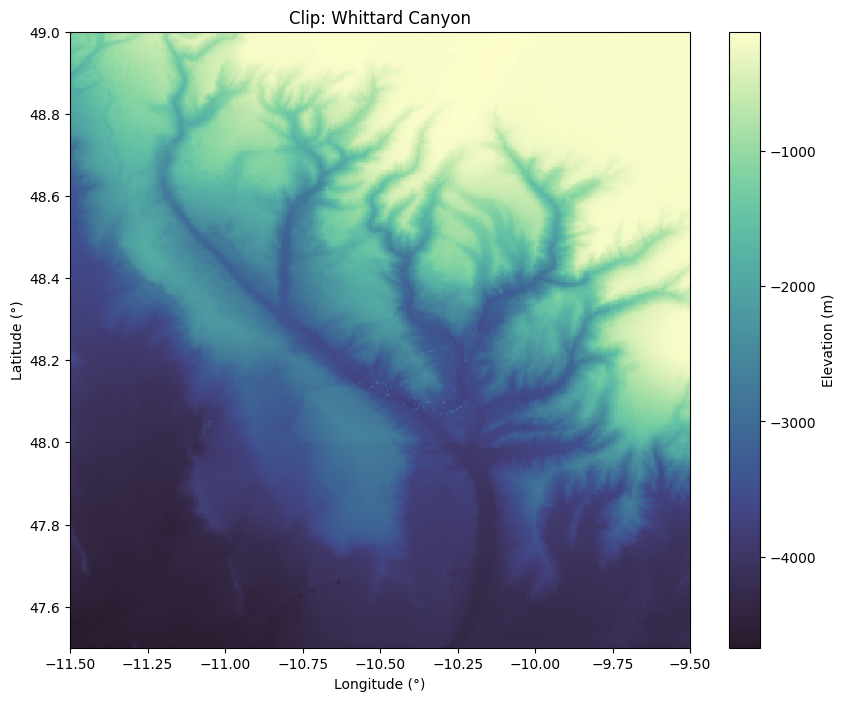

In [9]:
whittard = gpd.GeoDataFrame(geometry=[box(-11.5, 47.5, -9.5, 49)], crs="EPSG:4326")
subset = bathy.clip(data, geometry=whittard)

bathy.plot_bathy(subset)
plt.title("Clip: Whittard Canyon")
plt.show()

## Resample

* Change grid resolution. 
* GEBCO 2025 is ~450 m, here we downsample to ~2 km. You can specify resolution in metres (`resolution_m`) or degrees (`resolution_degrees`).

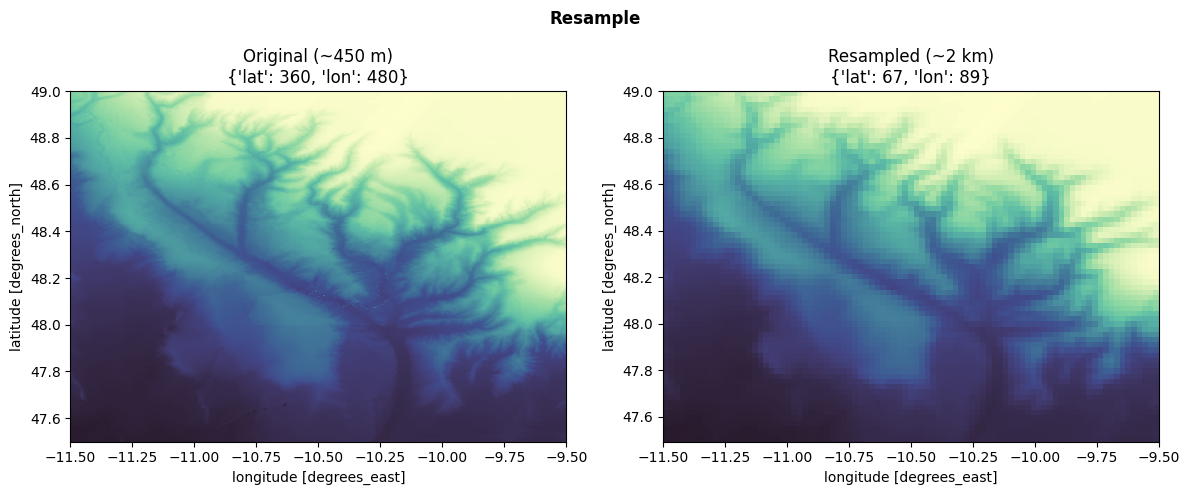

In [10]:
coarse = bathy.resample(subset, resolution_m=2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
subset.where(subset < 0).plot(ax=axes[0], cmap="cmo.deep_r", add_colorbar=False)
axes[0].set_title(f"Original (~450 m)\n{dict(subset.sizes)}")
coarse.where(coarse < 0).plot(ax=axes[1], cmap="cmo.deep_r", add_colorbar=False)
axes[1].set_title(f"Resampled (~2 km)\n{dict(coarse.sizes)}")
fig.suptitle("Resample", fontweight="bold")
fig.tight_layout()
plt.show()

## Reproject

* Transform from geographic (lon/lat) to a projected CRS. 
* Dim names update automatically — `lon`/`lat` becomes `x`/`y`.

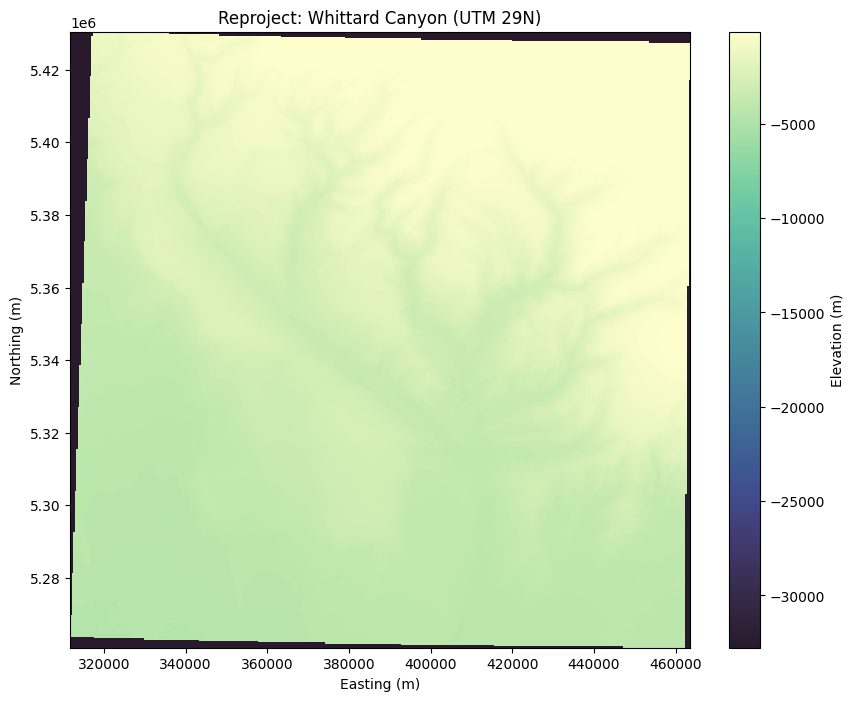

Dims: ('y', 'x')
CRS: EPSG:32629


In [11]:
utm = bathy.reproject(subset, target_crs="EPSG:32629")

bathy.plot_bathy(utm)
plt.title("Reproject: Whittard Canyon (UTM 29N)")
plt.show()

print(f"Dims: {utm.dims}")
print(f"CRS: {utm.rio.crs}")

## Merge

* Combine two overlapping tiles. 
* Overlapping cells are averaged by default (also supports `min`, `max`, `first`).

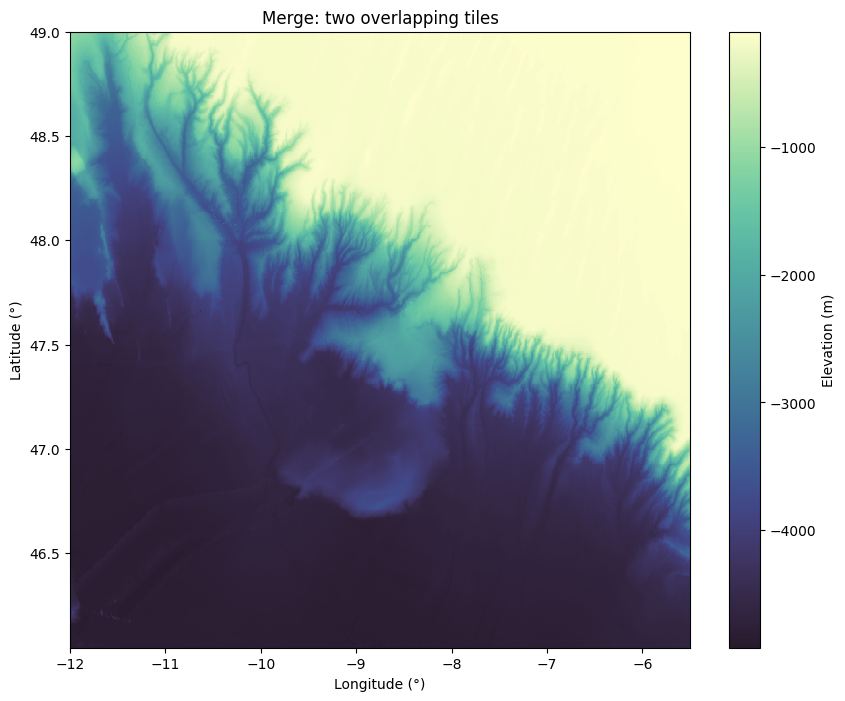

In [12]:
tile_a = bathy.clip(
    data, geometry=gpd.GeoDataFrame(geometry=[box(-12, 46, -8, 49)], crs="EPSG:4326")
)
tile_b = bathy.clip(
    data, geometry=gpd.GeoDataFrame(geometry=[box(-9, 46, -5.5, 49)], crs="EPSG:4326")
)
merged = bathy.merge([tile_a, tile_b])

bathy.plot_bathy(merged)
plt.title("Merge: two overlapping tiles")
plt.show()

## Fill Gaps

* Interpolate over NaN regions in a grid. 
* Supports `nearest` and `linear` methods.

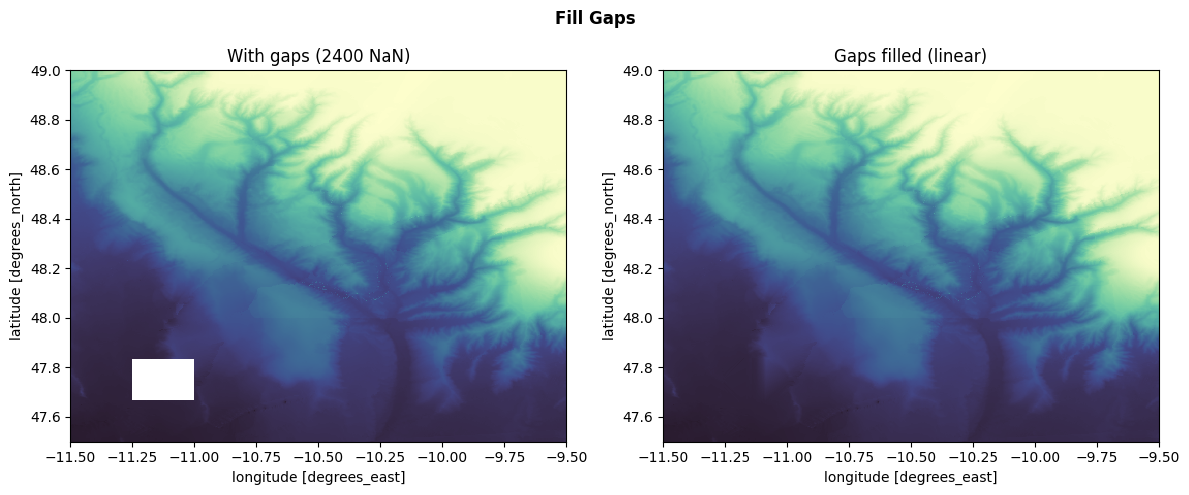

In [13]:
arr = subset.values.astype(float)
arr[40:80, 60:120] = np.nan
gappy = subset.copy(data=arr)
filled = bathy.fill_gaps(gappy, method="linear")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gappy.where(gappy < 0).plot(ax=axes[0], cmap="cmo.deep_r", add_colorbar=False)
axes[0].set_title(f"With gaps ({int(np.isnan(gappy.values).sum())} NaN)")
filled.where(filled < 0).plot(ax=axes[1], cmap="cmo.deep_r", add_colorbar=False)
axes[1].set_title("Gaps filled (linear)")
fig.suptitle("Fill Gaps", fontweight="bold")
fig.tight_layout()
plt.show()